In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
model = "gpt2-xl"
template = "0_shot"
datasets = {
    "tony_zhao/sst2": "SST-2"
}
num_samples = [50, 100, 200, 400, 800, 1000]
methods = {
    "baseline": {"label": "No adaptation", "color": "black", "linestyle": "--"},
    # "affine_alpha=matrix_bias=True_loss=log-loss": {"label": "Affine Matrix", "color": "tab:red"},
    "affine_alpha=vector_bias=True_loss=log-loss": {"label": "Affine Vector", "color": "tab:blue"},
}
metrics = {
    "error_rate": "Error Rate",
}

random_state = 27348

In [6]:
def compute_metric(logits, labels, metric="error_rate", bootstrap=False, num_samples=1000, random_state=0):

    def _compute_metric(logits, labels, metric="error_rate"):
        if metric == "error_rate":
            return np.mean(np.argmax(logits, axis=1) != labels)
        else:
            raise ValueError("Invalid metric: %s" % metric)

    if bootstrap:
        rs = np.random.RandomState(random_state)
        metrics = []
        for _ in range(num_samples):
            idx = rs.randint(0, len(logits), len(logits))
            metrics.append(_compute_metric(logits[idx], labels[idx], metric=metric))
    else:
        metrics = [_compute_metric(logits, labels, metric=metric)]

    return metrics

        

(<Figure size 500x500 with 1 Axes>,
 array([[<Axes: title={'center': 'SST-2'}, ylabel='Error Rate'>]],
       dtype=object))

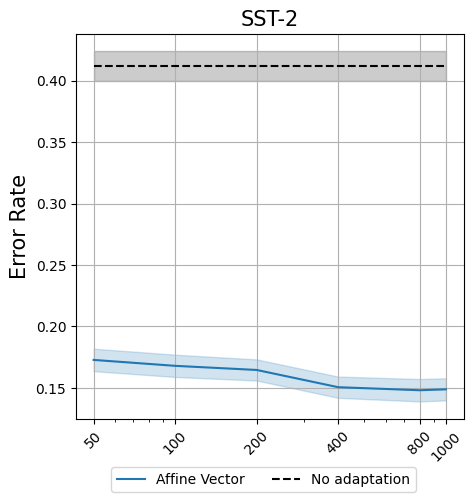

In [7]:
def plot_samples_vs_metric(
    model,
    template,
    datasets,
    num_samples,
    methods,
    metrics,
):
    fig, ax = plt.subplots(len(metrics), len(datasets), figsize=(len(datasets) * 5, len(metrics) * 5))
    if len(metrics) == 1 and len(datasets) == 1:
        ax = np.array([[ax]])
    elif len(metrics) == 1:
        ax = ax.reshape(-1, 1)
    elif len(datasets) == 1:
        ax = ax.reshape(1, -1)
    for i, dataset in enumerate(datasets):
        for j, metric in enumerate(metrics):
            for method in methods:
                if method == "baseline":
                    logits = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/test/{template}/logits.npy")
                    labels = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/test/{template}/labels.npy")
                    metric_values = compute_metric(logits, labels, metric=metric, bootstrap=True, num_samples=100, random_state=random_state)
                    means = np.ones(len(num_samples)) * np.mean(metric_values)
                    stds = np.ones(len(num_samples)) * np.std(metric_values)
                else:
                    means, stds = [], []
                    for n in num_samples:
                        logits = np.load(f"../results/calibrate_features/{model}/{dataset}/{template}--{n}/{method}/calibrated_posteriors.npy")
                        labels = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/test/{template}/labels.npy")
                        metric_values = compute_metric(logits, labels, metric=metric, bootstrap=True, num_samples=100, random_state=random_state)
                        means.append(np.mean(metric_values))
                        stds.append(np.std(metric_values))
                    means = np.array(means)
                    stds = np.array(stds)
                ax[i,j].plot(num_samples, means, **methods[method])
                ax[i,j].fill_between(num_samples, means - stds, means + stds, alpha=0.2, color=methods[method]["color"])
            ax[i,j].set_xscale("log")
            ax[i,j].set_xticks(num_samples)
            ax[i,j].set_xticklabels(num_samples, fontsize=10, rotation=45)
            if j == 0:
                    ax[i,j].set_title(datasets[dataset], fontsize=15)
        if i == 0:
            ax[i,j].set_ylabel(metrics[metric], fontsize=15)

        ax[i,j].grid()

    # Unique legend showing under all subplots
    handles, labels = ax[0,0].get_legend_handles_labels()
    unique_labels = list(set(labels))
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    fig.legend(unique_handles, unique_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(unique_labels), fontsize=10)
    return fig, ax

plot_samples_vs_metric(model, template, datasets, num_samples, methods, metrics)
